<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Line Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on using line charts to analyze trends over time and across different categories in a dataset.



## Objectives


In this lab you will perform the following:


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 151.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 173.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 162.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 176.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



#### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  9.11MB/s    in 22s     

2026-08-31 12:44:44 (6.81 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


#### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt


#### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")


#### Display the first few rows to understand the structure of the data


In [7]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


In [8]:
# Let's check the relevant columns
df[["Age", "ConvertedCompYearly"]].head()

,Age,ConvertedCompYearly
0,Under 18 years old,NaN
1,35-44 years old,NaN
2,45-54 years old,NaN
3,18-24 years old,NaN
4,18-24 years old,NaN


In [9]:
# And check Age counts
df["Age"].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [11]:
# First let's update the Age categories from shorter names as we've done in previous assessemnts
# Let's update the Age Groups as we've done in previous assessments
age_mapping = {
    "Under 18 years old": "<18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}

df["Age"] = df["Age"].replace(age_mapping)

In [12]:
# Now let's calculate the median compensation by age group
# Since we want a meaningful comparison, exclude missing compensation values
median_comp_by_age = (
    df.dropna(subset=["Age", "ConvertedCompYearly"])
      .groupby("Age")["ConvertedCompYearly"]
      .median()
)

median_comp_by_age

Age
18-24                 25000.0
25-34                 59825.0
35-44                 84796.0
45-54                 99099.0
55-64                109691.0
65+                  106000.0
<18                    7626.5
Prefer not to say    140000.0
Name: ConvertedCompYearly, dtype: float64

In [13]:
# As you can see, roupby() will sort the age groups alphabetically, which isn't what we want for a line chart
# Let's put the age groups in the correct order
age_order = [
    "<18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

median_comp_by_age = median_comp_by_age.reindex(age_order)

median_comp_by_age

Age
<18        7626.5
18-24     25000.0
25-34     59825.0
35-44     84796.0
45-54     99099.0
55-64    109691.0
65+      106000.0
Name: ConvertedCompYearly, dtype: float64

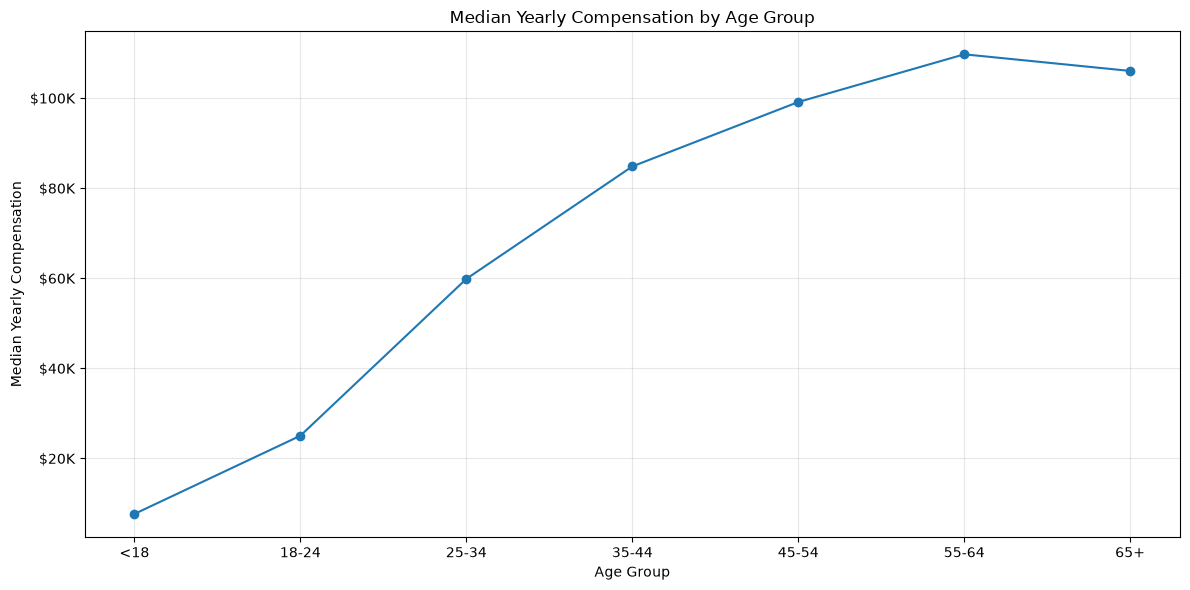

In [15]:
# Now Let's create our LineChart
from matplotlib.ticker import FuncFormatter

def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"
        
plt.figure(figsize=(12, 6))

plt.plot(
    median_comp_by_age.index,
    median_comp_by_age.values,
    marker="o"
)

plt.title("Median Yearly Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000:.0f}K")
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


In [16]:
# Since Age column contains age ranges, you can't isolate individual ages 25 through 45
# Let's use the groups 25-34 and 35-44 so that we can isolate 25-44
age_25_45 = [
    "25-34",
    "35-44"
]

df_25_45 = df[
    df["Age"].isin(age_25_45)
].copy()

In [17]:
# Calculate medium compensation
median_comp_25_45 = (
    df_25_45
    .dropna(subset=["ConvertedCompYearly"])
    .groupby("Age")["ConvertedCompYearly"]
    .median()
    .reindex(age_25_45)
)

median_comp_25_45

Age
25-34    59825.0
35-44    84796.0
Name: ConvertedCompYearly, dtype: float64

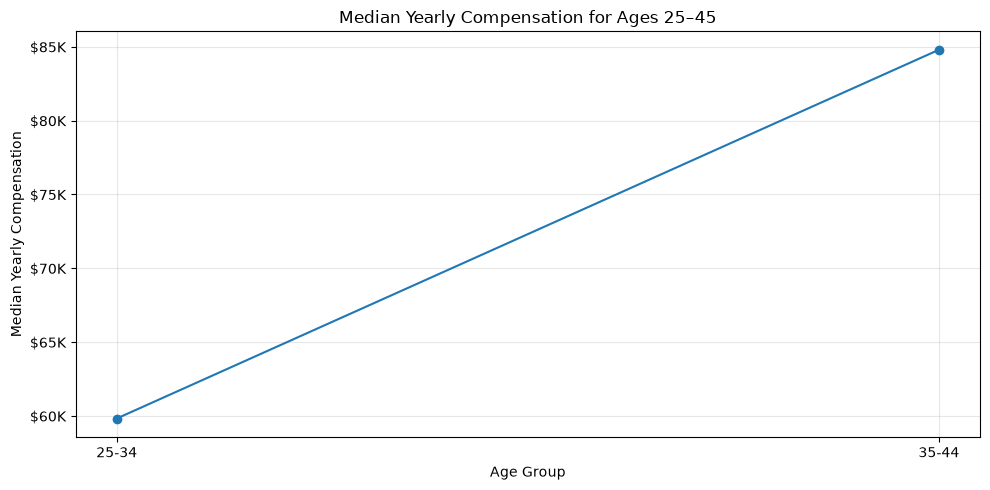

In [18]:
# Visualize our Line Chart
plt.figure(figsize=(10, 5))

plt.plot(
    median_comp_25_45.index,
    median_comp_25_45.values,
    marker="o"
)

plt.title("Median Yearly Compensation for Ages 25–45")
plt.xlabel("Age Group")
plt.ylabel("Median Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000:.0f}K")
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 2: Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


In [19]:
# Let's check the columns
df[["YearsCodePro", "JobSatPoints_6"]].head()

,YearsCodePro,JobSatPoints_6
0,NaN,NaN
1,17,0.0
2,27,NaN
3,NaN,NaN
4,NaN,NaN


In [20]:
# and values
print(df["YearsCodePro"].unique())
print(df["JobSatPoints_6"].describe())

<ArrowStringArray>
[                 nan,                 '17',                 '27',
                  '7',                 '11',                 '25',
                 '12',                 '10',                  '3',
   'Less than 1 year',                 '18',                 '37',
                 '15',                 '20',                  '6',
                  '2',                 '16',                  '8',
                 '14',                  '4',                 '45',
                  '1',                 '24',                 '29',
                  '5',                 '30',                 '26',
                  '9',                 '33',                 '13',
                 '35',                 '23',                 '22',
                 '31',                 '19',                 '21',
                 '28',                 '34',                 '32',
                 '40',                 '50',                 '39',
                 '44',                 '42'

In [21]:
# YearsCodePro contains values such as "Less than 1 year" and "More than 50 years", Let's convert them into numerical values
df["YearsCodeProNumeric"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0.5,
    "More than 50 years": 51
})

df["YearsCodeProNumeric"] = pd.to_numeric(
    df["YearsCodeProNumeric"],
    errors="coerce"
)

In [22]:
# Calculate median job satisfaction by experience
median_jobsat_experience = (
    df.dropna(subset=["YearsCodeProNumeric", "JobSatPoints_6"])
      .groupby("YearsCodeProNumeric")["JobSatPoints_6"]
      .median()
)

median_jobsat_experience.head()

YearsCodeProNumeric
0.5    10.0
1.0    15.0
2.0    15.0
3.0    20.0
4.0    20.0
Name: JobSatPoints_6, dtype: float64

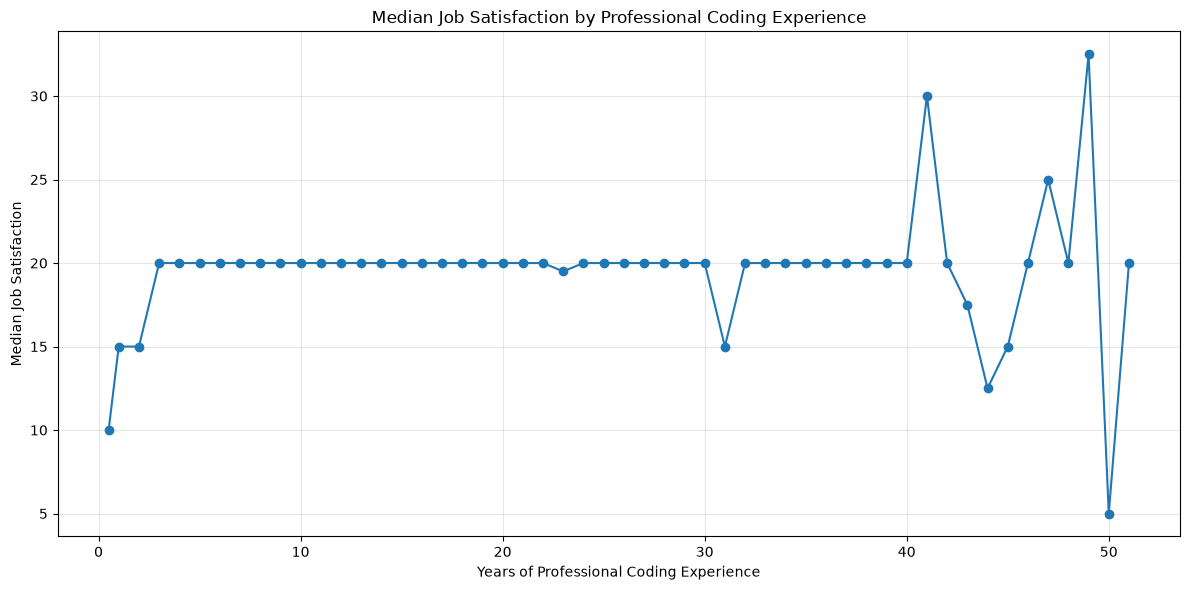

In [23]:
# Visualize our LineChart
plt.figure(figsize=(12, 6))

plt.plot(
    median_jobsat_experience.index,
    median_jobsat_experience.values,
    marker="o"
)

plt.title("Median Job Satisfaction by Professional Coding Experience")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Median Job Satisfaction")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3: Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


In [24]:
# Let's check WorkExp
df[["WorkExp", "ConvertedCompYearly"]].head()

,WorkExp,ConvertedCompYearly
0,NaN,NaN
1,17.0,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [25]:
# Calculate median compensation by experience without missing values
median_comp_by_exp = (
    df.dropna(subset=["WorkExp", "ConvertedCompYearly"])
      .groupby("WorkExp")["ConvertedCompYearly"]
      .median()
      .sort_index()
)

median_comp_by_exp

WorkExp
0.0      13306.0
1.0      20077.0
2.0      27968.5
3.0      34896.0
4.0      42962.0
5.0      51624.0
6.0      57140.0
7.0      64444.0
8.0      69814.0
9.0      73932.0
10.0     75000.0
11.0     85000.0
12.0     81629.0
13.0     85348.5
14.0     85925.0
15.0     85925.0
16.0     92708.0
17.0     93000.0
18.0     92146.0
19.0    100500.0
20.0     92369.0
21.0     91295.0
22.0     98956.5
23.0    104184.0
24.0    105405.0
25.0    104000.0
26.0    105000.0
27.0    108943.5
28.0    109504.5
29.0    102036.0
30.0    107406.0
31.0     91719.0
32.0    112312.0
33.0    123517.0
34.0    145345.0
35.0    107406.0
36.0    112601.0
37.0    128887.0
38.0    120000.0
39.0    101910.0
40.0    140000.0
41.0    131000.0
42.0    135000.0
43.0    100914.5
44.0     97258.5
45.0    123334.0
46.0     96496.5
47.0    100000.0
48.0    110000.0
49.0    109959.5
50.0    136000.0
Name: ConvertedCompYearly, dtype: float64

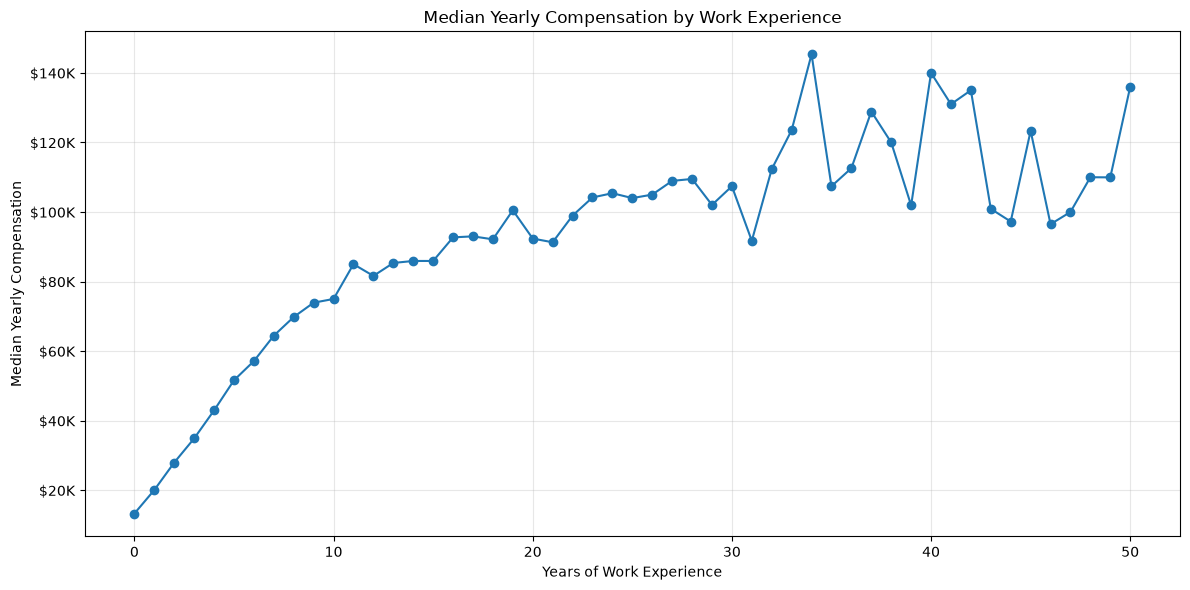

In [26]:
# Visualizing Line Chart
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))

plt.plot(
    median_comp_by_exp.index,
    median_comp_by_exp.values,
    marker="o"
)

plt.title("Median Yearly Compensation by Work Experience")
plt.xlabel("Years of Work Experience")
plt.ylabel("Median Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000:.0f}K")
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


In [27]:
# Let's calculate median job satisfaction by experience
median_jobsat_by_exp = (
    df.dropna(subset=["WorkExp", "JobSatPoints_6"])
      .groupby("WorkExp")["JobSatPoints_6"]
      .median()
      .sort_index()
)

median_jobsat_by_exp

WorkExp
0.0      5.0
1.0     10.0
2.0     15.0
3.0     20.0
4.0     20.0
5.0     20.0
6.0     20.0
7.0     20.0
8.0     20.0
9.0     20.0
10.0    20.0
11.0    20.0
12.0    20.0
13.0    20.0
14.0    20.0
15.0    18.0
16.0    20.0
17.0    20.0
18.0    20.0
19.0    20.0
20.0    15.0
21.0    20.0
22.0    20.0
23.0    20.0
24.0    20.0
25.0    20.0
26.0    18.5
27.0    20.0
28.0    20.0
29.0    20.0
30.0    15.0
31.0    15.0
32.0    20.0
33.0    15.0
34.0    20.0
35.0    15.0
36.0    20.0
37.0    20.0
38.0    10.0
39.0    20.0
40.0    20.0
41.0    10.0
42.0    20.0
43.0    20.0
44.0    12.5
45.0    20.0
46.0    30.0
47.0    20.0
48.0    10.0
49.0    17.5
50.0    10.0
Name: JobSatPoints_6, dtype: float64

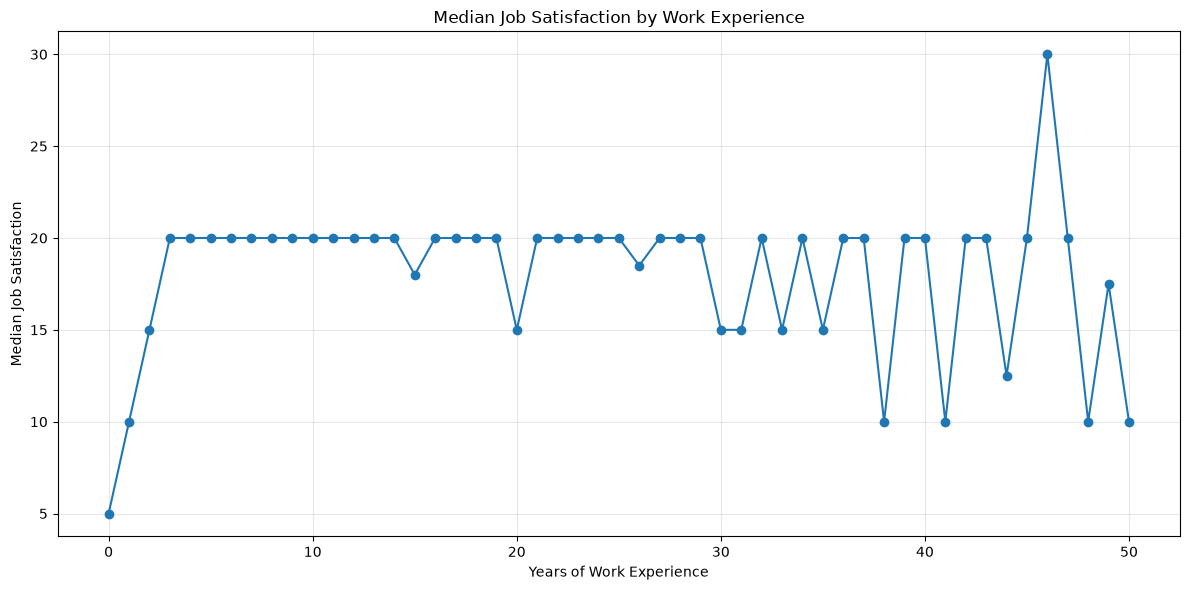

In [28]:
# Visualizing LineChart
plt.figure(figsize=(12, 6))

plt.plot(
    median_jobsat_by_exp.index,
    median_jobsat_by_exp.values,
    marker="o"
)

plt.title("Median Job Satisfaction by Work Experience")
plt.xlabel("Years of Work Experience")
plt.ylabel("Median Job Satisfaction")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Final Step: Review


In this lab, you focused on analyzing trends in compensation and job satisfaction, specifically exploring how these metrics change with age and experience levels using line charts.


### Summary


In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
